In [2]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [3]:
# lets import the dataset (here we are gonna use processed_datatcsv)
df = pd.read_csv("processed_data.csv")

In [4]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [5]:
# lets do train test split
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop("status", axis=1),df["status"],test_size = 0.2,random_state=1)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=15000), "clean_text"),   # preprocessed text
    ("num", StandardScaler(), num_cols)             # numeric features
])

In [7]:
# lets import the model
import lightgbm as lgb

In [8]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

lgbm_pipeline = Pipeline([
    ("preprocess", preprocessor),  # your existing ColumnTransformer
    ("model", LGBMClassifier(
        objective="multiclass",
        num_class=7,
        random_state=42,
        n_jobs=-1
    ))
])

In [9]:
lgbm_pipeline.fit(xtrain, ytrain)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.319843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 332199
[LightGBM] [Info] Number of data points in the train set: 42036, number of used features: 6210
[LightGBM] [Info] Start training from score -1.179595
[LightGBM] [Info] Start training from score -1.227871
[LightGBM] [Info] Start training from score -1.595523
[LightGBM] [Info] Start training from score -2.607447
[LightGBM] [Info] Start training from score -2.930266
[LightGBM] [Info] Start training from score -3.008565
[LightGBM] [Info] Start training from score -3.891678


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=15000),
                                                  'clean_text'),
                                                 ('num', StandardScaler(),
                                                  ['statement_length',
                                                   'num_words',
                                                   'vocabulary_size',
                                                   'avg_word_length'])])),
                ('model',
                 LGBMClassifier(n_jobs=-1, num_class=7, objective='multiclass',
                                random_state=42))])

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3291
           1       0.71      0.74      0.73      3090
           2       0.70      0.66      0.68      2122
           3       0.79      0.80      0.79       742
           4       0.89      0.78      0.83       533
           5       0.69      0.51      0.59       512
           6       0.89      0.65      0.75       219

    accuracy                           0.78     10509
   macro avg       0.79      0.73      0.75     10509
weighted avg       0.78      0.78      0.78     10509



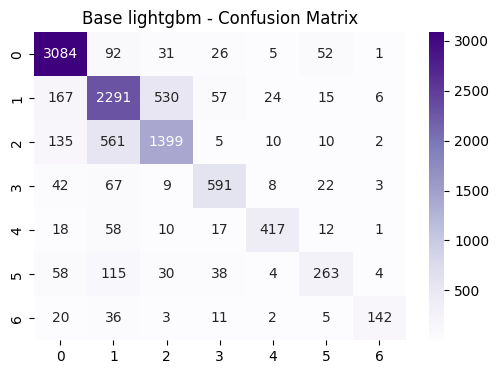

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = lgbm_pipeline.predict(xtest)

print(classification_report(ytest, y_pred))

cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Base lightgbm - Confusion Matrix")
plt.show()

In [11]:
# i can clearly observe that lightgbm id clearly outperforming the other models in this basic tunning 
# also it takes less than a minute while training but while other models takes 10 to 12 minutes 


In [12]:
# lets now finetune the model


In [13]:
# here we have xtrain,ytrain, xtest,ytest

In [14]:
# now again make a object for column tranformer
tuneprocessor = ColumnTransformer([
    ("text",TfidfVectorizer(),"clean_text"),
    ("num",StandardScaler(),num_cols)
])

In [27]:
# now make a pipeline for model 

tunepipeline = Pipeline([
    ("preprocess",tuneprocessor),
    ("model",LGBMClassifier(objective="multiclass",
                            num_class = 7,random_state=2
                            ,n_jobs=-1))

])

In [46]:
# now make a object for the paramerters for tunning with ramdomsearchcv
from scipy.stats import randint, uniform
grid = { 
    # for preprocess(name in pipeline)
    "preprocess__text__max_features":[20000,15000],
    "preprocess__text__ngram_range":[(1,2)],
    # "preprocess__text__min_df": [2, 5, 10],
    # "preprocess__text__max_df": [0.9, 0.95],

    # for model
    "model__n_estimators": randint(300, 900),
    "model__learning_rate": uniform(0.01, 0.15),
    "model__num_leaves": randint(30, 150),
    "model__max_depth": randint(5, 15),
    "model__min_child_samples": randint(20, 120),

    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),

    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0, 1)
}

In [47]:
# now lets do make a randomcv
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
    tunepipeline,
    param_distributions=grid,
    n_iter=10,
    scoring="f1_weighted",
    cv=2,
    verbose=3,
    n_jobs=-1,
    random_state=42
)

In [48]:
# lets train it
search.fit(xtrain,ytrain)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.563782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 494526
[LightGBM] [Info] Number of data points in the train set: 42036, number of used features: 12967
[LightGBM] [Info] Start training from score -1.179595
[LightGBM] [Info] Start training from score -1.227871
[LightGBM] [Info] Start training from score -1.595523
[LightGBM] [Info] Start training from score -2.607447
[LightGBM] [Info] Start training from score -2.930266
[LightGBM] [Info] Start training from score -3.008565
[LightGBM] [Info] Start training from score -3.891678
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(),
                                                                               'clean_text'),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['statement_length',
                                                                                'num_words',
                                                                                'vocabulary_size',
                                                                                'avg_word_length'])])),
                                             ('model',
                                              LGBMClassifier(n_jobs=-1,
                                                             num_class=7,
                                                             objective='multiclass',
                                                             random_state=2))]),
                   n_jobs=-1,
                   param_distributions...
                                        'model__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000205A9D9E610>,
                                        'model__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000205A9D9E010>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000205A9CBA210>,
                                        'preprocess__text__max_features': [20000,
                                                                           15000],
                                        'preprocess__text__ngram_range': [(1,
                                                                           2)]},
                   random_state=42, scoring='f1_weighted', verbose=3)

In [49]:
search.best_score_

0.7579490163894709

## Model Performance observation

In [50]:
search.best_params_

{'model__colsample_bytree': 0.8827429375390468,
 'model__learning_rate': 0.11935107520614809,
 'model__max_depth': 5,
 'model__min_child_samples': 24,
 'model__n_estimators': 789,
 'model__num_leaves': 132,
 'model__reg_alpha': 0.6510770255019445,
 'model__reg_lambda': 0.9149596755437808,
 'model__subsample': 0.9400154311159197,
 'preprocess__text__max_features': 15000,
 'preprocess__text__ngram_range': (1, 2)}

In [42]:
search.cv_results_

{'mean_fit_time': array([209.14151931, 350.12668157]),
 'std_fit_time': array([5.06183672, 0.59967875]),
 'mean_score_time': array([6.73075867, 6.21706259]),
 'std_score_time': array([0.16427779, 0.15460217]),
 'param_model__colsample_bytree': masked_array(data=[0.749816047538945, 0.6571467271687763],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_model__learning_rate': masked_array(data=[0.15260714596148742, 0.10763327094232793],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_model__max_depth': masked_array(data=[12, 9],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_model__min_child_samples': masked_array(data=[80, 21],
              mask=[False, False],
        fill_value='?',
             dtype=object),
 'param_model__n_estimators': masked_array(data=[320, 643],
              mask=[False, False],
        fill_value='?',
             dtype=o

In [51]:
import pandas as pd

df_results = pd.DataFrame(search.cv_results_)

df_results = df_results.sort_values(by="rank_test_score")

df_results[[
    "rank_test_score",
    "mean_test_score",
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_preprocess__text__ngram_range",
    "param_preprocess__text__max_features"
]]

,rank_test_score,mean_test_score,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_preprocess__text__ngram_range,param_preprocess__text__max_features
9,1,0.757949,789,0.119351,132,"(1, 2)",15000
4,2,0.755717,645,0.152333,82,"(1, 2)",15000
3,3,0.750453,543,0.127776,93,"(1, 2)",20000
1,4,0.749025,643,0.116211,137,"(1, 2)",20000
6,5,0.748945,461,0.155438,103,"(1, 2)",15000
0,6,0.748452,320,0.152607,132,"(1, 2)",20000
2,7,0.747945,774,0.088713,88,"(1, 2)",20000
8,8,0.747648,820,0.054441,117,"(1, 2)",20000
7,9,0.745995,637,0.088125,140,"(1, 2)",15000
5,10,0.738987,861,0.015158,133,"(1, 2)",15000


In [59]:
# lets find out the corelation 
df_results.info()
# print(df_results.corr()["mean_test_score"].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 9 to 5
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   mean_fit_time                         10 non-null     float64
 1   std_fit_time                          10 non-null     float64
 2   mean_score_time                       10 non-null     float64
 3   std_score_time                        10 non-null     float64
 4   param_model__colsample_bytree         10 non-null     object 
 5   param_model__learning_rate            10 non-null     object 
 6   param_model__max_depth                10 non-null     object 
 7   param_model__min_child_samples        10 non-null     object 
 8   param_model__n_estimators             10 non-null     object 
 9   param_model__num_leaves               10 non-null     object 
 10  param_model__reg_alpha                10 non-null     object 
 11  param_model__reg_lambda    

In [63]:

df_clean = df_results.copy()

param_cols = [col for col in df_clean.columns if col.startswith("param_")]

df_params_only = df_clean[param_cols + ["mean_test_score"]]

In [64]:
for col in param_cols:
    df_params_only[col] = pd.to_numeric(df_params_only[col], errors="coerce")

C:\Users\Harsh\AppData\Local\Temp\ipykernel_25944\4222144730.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_params_only[col] = pd.to_numeric(df_params_only[col], errors="coerce")


In [65]:
df_numeric = df_params_only.select_dtypes(include=["number"])

In [66]:
corr = df_numeric.corr()["mean_test_score"].sort_values(ascending=False)

print(corr)

mean_test_score                         1.000000
param_model__learning_rate              0.694874
param_model__subsample                  0.510551
param_model__reg_lambda                 0.319760
param_model__colsample_bytree          -0.063765
param_preprocess__text__max_features   -0.083130
param_model__n_estimators              -0.149197
param_model__max_depth                 -0.166881
param_model__num_leaves                -0.328917
param_model__reg_alpha                 -0.342129
param_model__min_child_samples         -0.540828
param_preprocess__text__ngram_range          NaN
Name: mean_test_score, dtype: float64


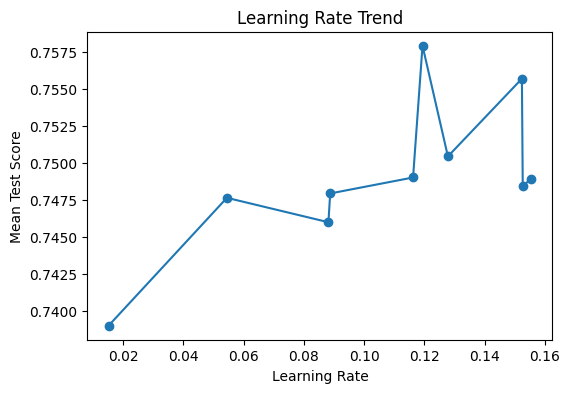

In [68]:
# lets make graph to understnd relation of number feature with learning rate and others
df_sorted = df_clean.sort_values("param_model__learning_rate")

plt.figure(figsize=(6,4))
plt.plot(
    df_sorted["param_model__learning_rate"],
    df_sorted["mean_test_score"],
    marker='o'
)
plt.xlabel("Learning Rate")
plt.ylabel("Mean Test Score")
plt.title("Learning Rate Trend")

plt.show()

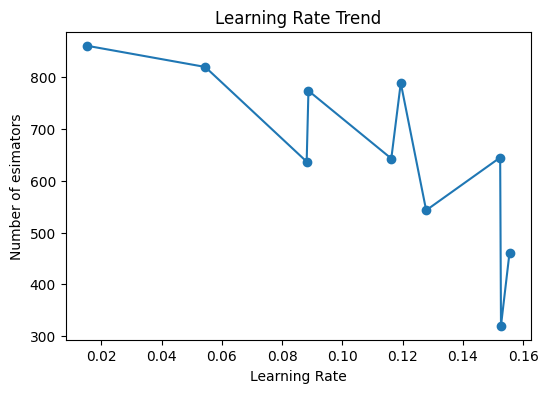

 here is the direcyt relation that 
        --> when we increase the number of esimators  there the learning rate also decreases
        --> but also form previous graph we can see that with higher learning rate produces better result


In [80]:
df_sorted = df_clean.sort_values("param_model__learning_rate")

plt.figure(figsize=(6,4))
plt.plot(
    df_sorted["param_model__learning_rate"],
    df_sorted["param_model__n_estimators"],
    marker='o'
)
plt.xlabel("Learning Rate")
plt.ylabel("Number of esimators")
plt.title("Learning Rate Trend")
plt.show()

print(''' here is the direcyt relation that 
        --> when we increase the number of esimators  there the learning rate also decreases
        --> but also form previous graph we can see that with higher learning rate produces better result''')

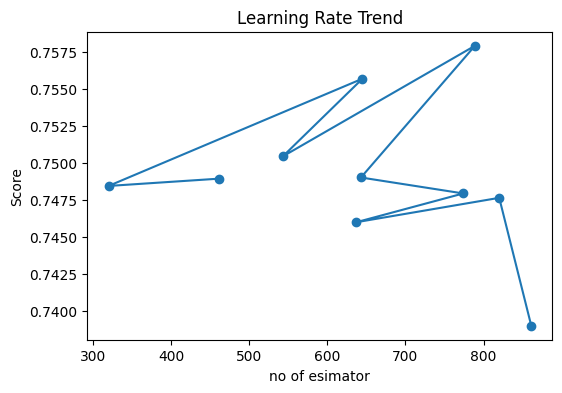

we can clearly observe the following points
                -> there is no direct relations with score and number of esimator as this is random search cv
                -> higer number of esimators leads to increease in performance 


In [78]:
df_sorted = df_clean.sort_values("param_model__learning_rate")

plt.figure(figsize=(6,4))
plt.plot(
    
    df_sorted["param_model__n_estimators"],
    df_sorted["mean_test_score"],
    marker='o'
)
plt.ylabel("Score")
plt.xlabel("no of esimator")
plt.title("Learning Rate Trend")
plt.show()
print('''we can clearly observe the following points
                -> there is no direct relations with score and number of esimator as this is random search cv
                -> higer number of esimators leads to increease in performance ''')

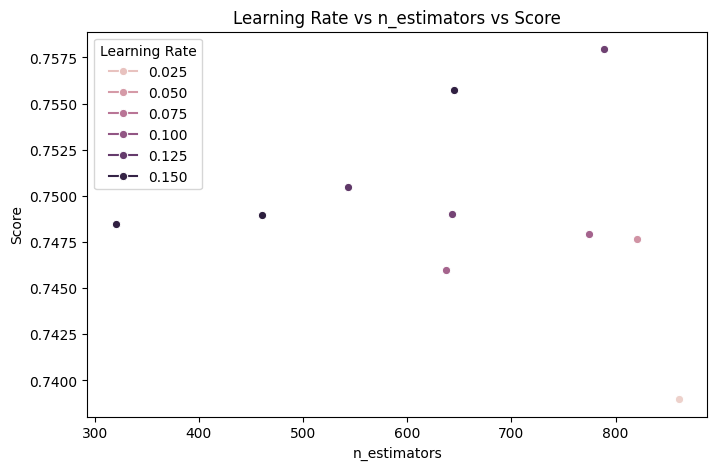

 here we can observe that higer learning rate and higer number of estimators shows good result


In [82]:
# lets understand the result better by plotting every feature relation with the number of esimators and the score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_clean.sort_values("param_model__n_estimators"),
    x="param_model__n_estimators",
    y="mean_test_score",
    hue="param_model__learning_rate",
    marker="o"
)

plt.title("Learning Rate vs n_estimators vs Score")
plt.xlabel("n_estimators")
plt.ylabel("Score")
plt.legend(title="Learning Rate")
plt.show()
print(''' here we can observe that higer learning rate and higer number of estimators shows good result''')

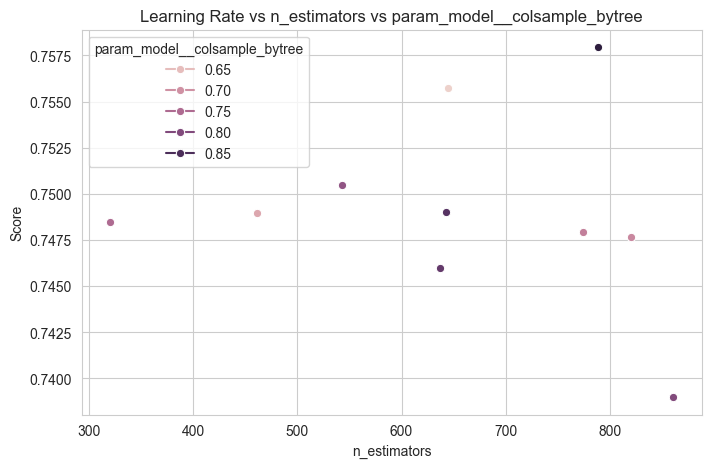

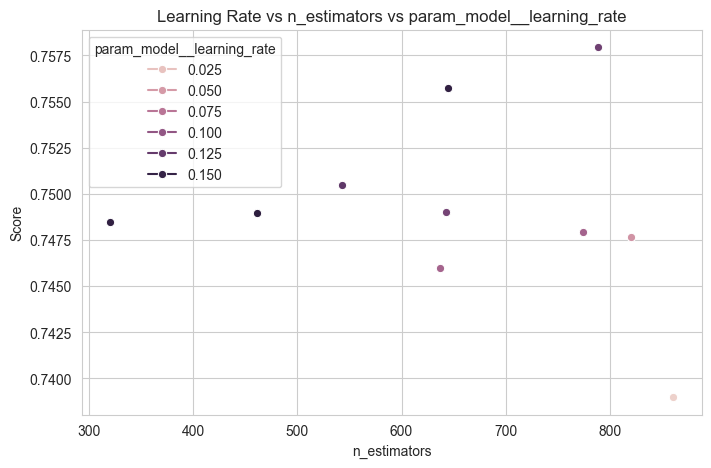

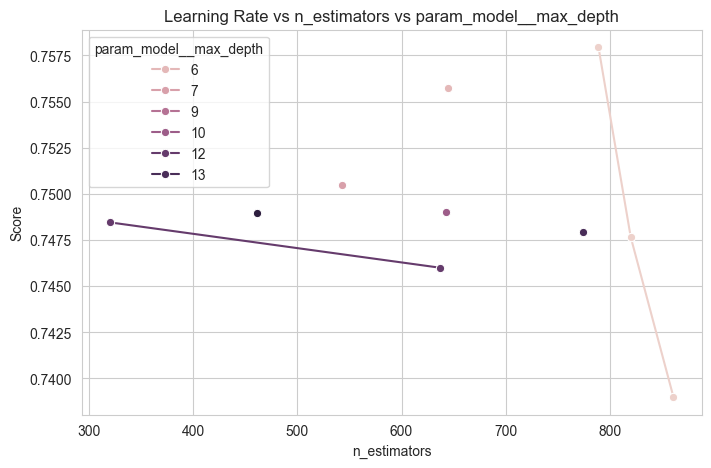

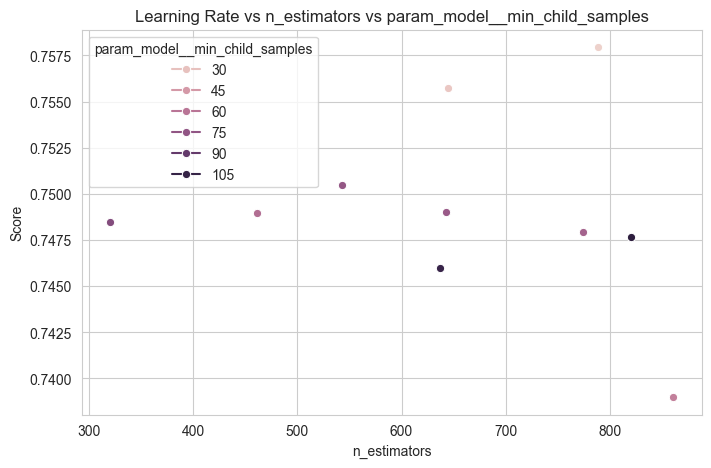

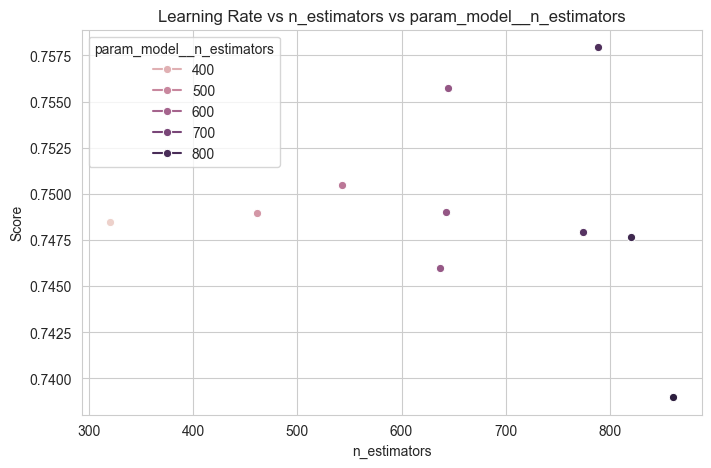

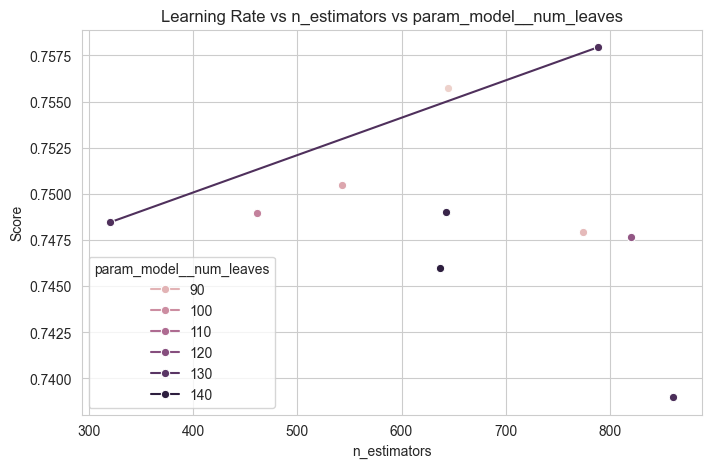

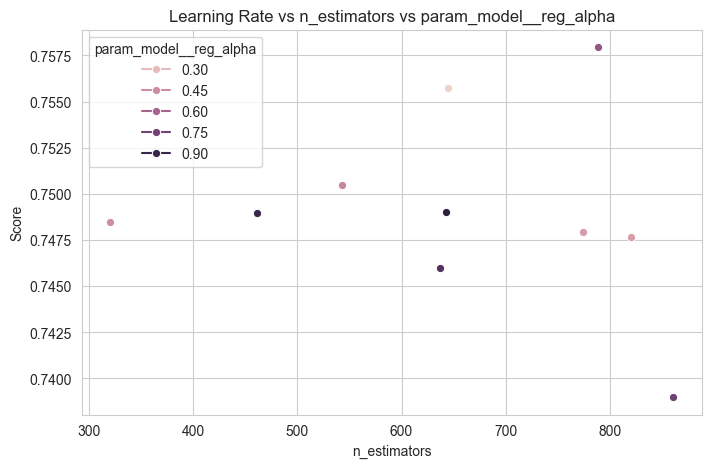

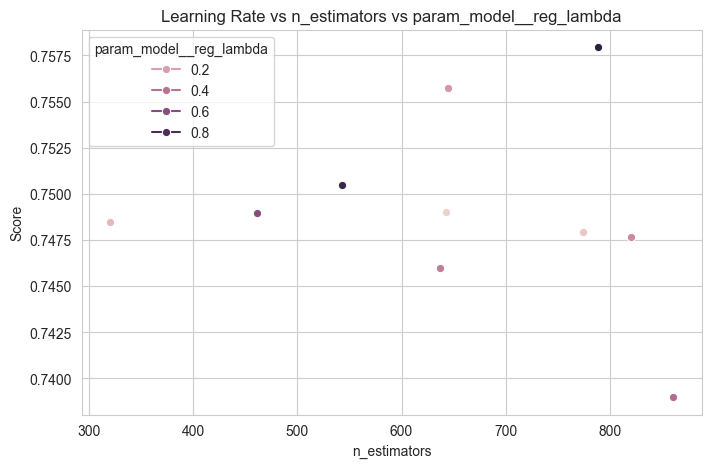

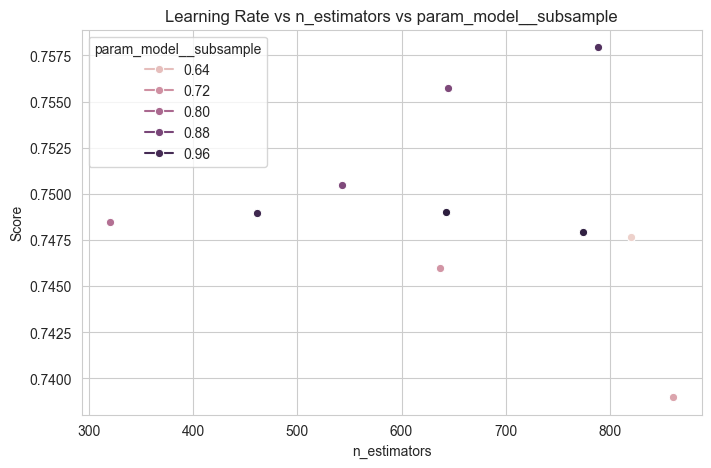

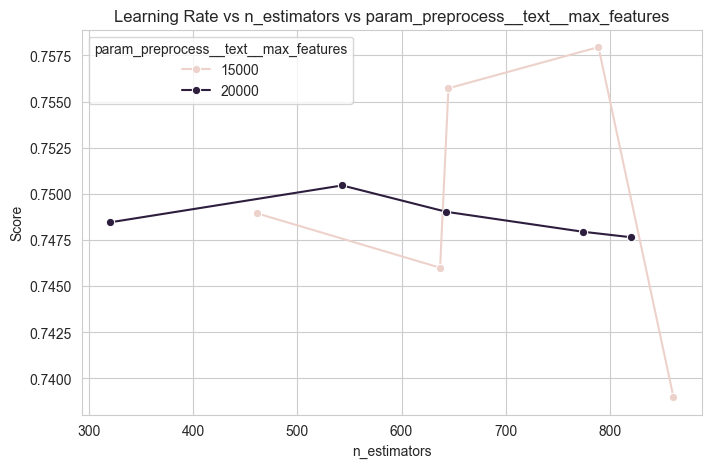

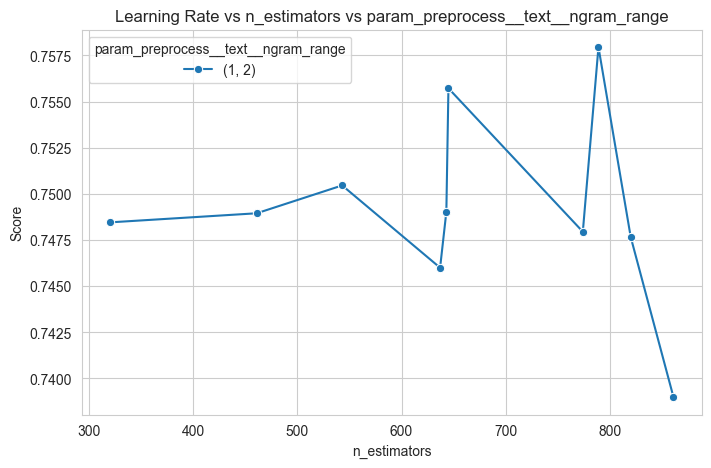

In [91]:
# lets plot for differnt more tree parameters
for i in param_cols:
    plt.figure(figsize=(8,5))

    sns.lineplot(
    data=df_clean.sort_values("param_model__n_estimators"),
    x="param_model__n_estimators",
    y="mean_test_score",
    hue=i,
    marker="o"
    )

    plt.title(f"Learning Rate vs n_estimators vs {i}")
    plt.xlabel("n_estimators")
    plt.ylabel("Score")
    plt.legend(title=i)
    plt.show()


In [92]:
# here we can clearly observe that the learning rate is affting the performance more 
# and also the lambda values and min_child_sample  (which control the regulirization  )

# also we can clearly see that max feature is not affteing tyhe performance means most important 
# feature comes under 10000 also 

# also we have to increase the threshold and also have to first make generiolazion model using random search with more  roder limits of paramerts
# next time we have only train the top featrue like learing rate ,and other regulirization features 
# by increasing the esimators upto 2k

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      3291
           1       0.70      0.74      0.72      3090
           2       0.70      0.65      0.67      2122
           3       0.81      0.82      0.81       742
           4       0.87      0.75      0.81       533
           5       0.69      0.52      0.59       512
           6       0.88      0.63      0.73       219

    accuracy                           0.78     10509
   macro avg       0.79      0.72      0.75     10509
weighted avg       0.78      0.78      0.78     10509



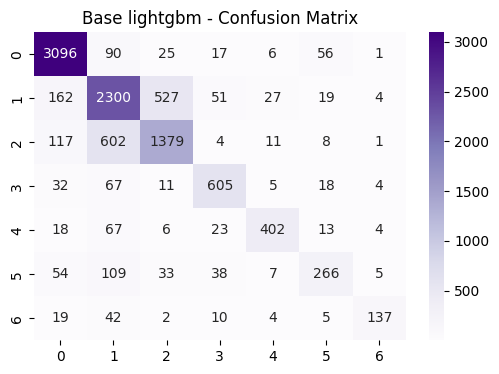

In [52]:
y_pred = search.best_estimator_.predict(xtest)

print(classification_report(ytest, y_pred))

cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Base lightgbm - Confusion Matrix")
plt.show()

In [ ]:
# performance is not improved much 